# **Single-Lead ECG Arrhythmia Classification**

Oleh : Alfonso Liguori Stanlin Dyas - S1 Teknik Biomedis, Universitas Telkom

### **Information about dataset:**

The dataset can be downloaded from the original website or by clicking the link directly. The overall information about the dataset is given here.

1. The MIT-BIH dataset contains 48 readings.
2. Number of patients = 47 (25 Men, 22 Women). Only 1 patient has 2 readings. Rest 1 readings/patients.
3. Each reading contains a. ECG signals b. Annotations
4. ECG signals length = 30 Minutes (or slightly over). Sampling Frequency = 360 Hz.
5. Each reading contains 2 Lead ECG signals that are Modified Limb Lead II and Modified Lead V1 (Occationally V2, V5, V4 just only once). Simply, Two Leads: MLII, V1.
6. Annotation is given for each beat. Although 20 types of beats are annotated in dataset. We consider only 15 types of beats grouped in 5 classes followed by the recommendation of AAMI.

- N - Normal
- S - Supraventricular premature beat
- V - Premature ventricular contraction
- F - Fusion of ventricular and normal beat
- Q - Unclassifiable / Unknown beat

### **Additional Dataset Information:**

The source of the ECGs included in the MIT-BIH Arrhythmia Database is a set of over 4000 long-term Holter recordings that were obtained by the Beth Israel Hospital Arrhythmia Laboratory between 1975 and 1979. Approximately 60% of these recordings were obtained from inpatients. The subjects were 25 men aged 32 to 89 years, and 22 women aged 23 to 89 years

Main Parts of the Study:
1. Part A: Installing Packages and Basic Visualization of ECG
2. Part B: Denoising, R-Peak Detection, Segmentation
3. Part C: Dataset Loading
4. Part D: Train-Test Splitting and Class Balancing
5. Part E: Model Building and Training
6. Part F: Results

### **15 types of beats grouped in 5 classes followed by the recommendation of AAMI**

1. **Normal (N)**
* N : Normal beat (P-wave jelas, QRS sempit, internal R-R reguler).
* L : Left bundle branch block beat (QRS melebar, morfologi M-shape di V1/V6).
* R : Right bundle branch block beat (QRS melebar, rSR' di V1).
* e : Atrial escape beat (Beat cadangan atrium muncul setelah sinus pause).
* j : Nodal (junctional) escape beat (AV node mengatur detak saat sinus node gagal).
2. **Supraventricular ectopic beat (S)**
* A : Atrial premature beat (Muncul lebih awal dari sinus normal, P-wave berbeda, QRS sempit).
* a : Aberrated atrial premature beat (Premature dengan QRS melebar karena blok konduksi fungsional).
* J : Nodal (junctional) premature beat (Premature dari AV node, P-wave bisa tersembunyi).
* S : Supraventricular premature beat (Umumnya di atrium atau nodal, QRS sempit).
3. **Ventricular ectopic beat (V)**
* V : Premature ventricular contraction (QRS lebar >120 ms, T-wave terbalik, tidak ada P-wave sebelum beat).
* E : Ventricular escape beat (Beat ventrikel muncul terlambat setelah sinus pause, QRS lebar).
4. **Fusion beat (F)**
* F : Fusion of ventricular and normal beat (Kombinasi normal + Premature Ventricular Contraction (PVC) -> QRS tampak campuran, gelombang P kadang terlihat sebagian).
5. **Unknown beat (Q)**
* / : Paced beat (Beat fusi pacemaker + normal/tidak dapat diklasifikasikan secara pasti).
* f : Fusion of paced and normal beat (Fusion pacemaker + ventricular beat).
* Q : Unclassifiable beat (Beat tidak dapat diklasifikasikan karena noise, artefak, atau bentuk yang tidak jelas).

## **Part 1: Importing Packages and Basic Visualization of ECG**

### **Part 1.1 : Importing & Installing Packages**

In [2]:
pip install wfdb

Note: you may need to restart the kernel to use updated packages.


In [68]:
pip install PyWavelets

Note: you may need to restart the kernel to use updated packages.


In [69]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [70]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [71]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [178]:
pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn][imbalanced-learn]
Note: you may need to restart the kernel to use updated packages.


In [212]:
pip install tensorboard

  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached markdown-3.10.2-py3-none-any.whl.metadata (5.1 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using cached markupsafe-3.0.3-cp310-cp310-macosx_11_0_arm64.whl.metadata (2.7 kB)
Using cached tensorboard-2.20.0-py3-none-any.whl (5.5 MB)
Using cached tensorboard_data_server-0.7.2-py3-none-any.whl (2.4 kB)
Using cached markdown-3.10.2-py3-none-any.whl (108 kB)
Using cached markupsafe-3.0.3-cp310-cp310-macosx_11_0_arm64.whl (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [tensorboard] [tensorboard]
Note: you may need to restart the kernel to use updated packages.


In [173]:
# Importing packages

import os
import datetime
import wfdb
import sys
import pywt
import seaborn
import numpy as np
import tensorflow as tf
import math
import sklearn
from math import ceil
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from os.path import join as osj
import pandas as pd

### **Part 1.2 : Basic Visualization of ECG**
Untuk memuat (membaca), memplot, dan mengolah sinyal EKG

In [137]:
DATA_ROOT = "/Users/alstanlin/Desktop/CAT-NET for Arrhythmia Detection/mitdata1"
RECORDS = os.path.join(DATA_ROOT, "RECORDS")

In [139]:
project_path = "/Users/alstanlin/Desktop/CAT-NET for Arrhythmia Detection/mitdata1"

In [74]:
patient_ids = pd.read_csv(RECORDS, header=None).to_numpy().reshape(-1)
patient_ids

array(['100', '101', '102', '103', '104', '105', '106', '107', '108',
       '109', '111', '112', '113', '114', '115', '116', '117', '118',
       '119', '121', '122', '123', '124', '#####', '200', '201', '202',
       '203', '205', '207', '208', '209', '210', '212', '213', '214',
       '215', '217', '219', '220', '221', '222', '223', '228', '230',
       '231', '232', '233', '234'], dtype=object)

In [ ]:
#Extracting just 1 patient ECG signal and info

lead0 = {} 
lead1 = {}
patient_id = 100
signals, info = wfdb.io.rdsamp(osj(DATA_ROOT, str(patient_id)))
lead0[patient_id] = signals[:, 0]
lead1[patient_id] = signals[:, 1]

<class 'numpy.ndarray'>
(650000,)
{'fs': 360, 'sig_len': 650000, 'n_sig': 2, 'base_date': None, 'base_time': None, 'units': ['mV', 'mV'], 'sig_name': ['MLII', 'V5'], 'comments': ['69 M 1085 1629 x1', 'Aldomet, Inderal']}


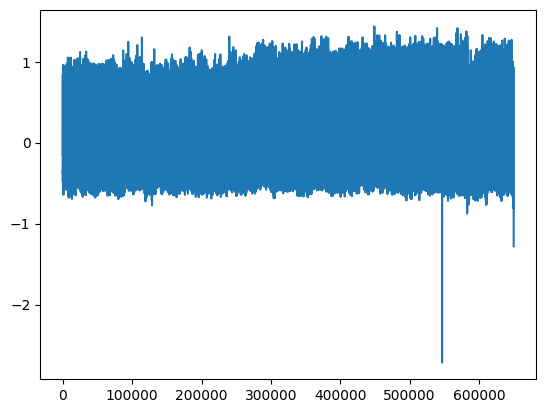

In [ ]:
# Visualization of 1 patients signal and info

print(type(lead0[patient_id]))
print(lead0[patient_id].shape)
plt.plot(lead0[patient_id])
print(info)

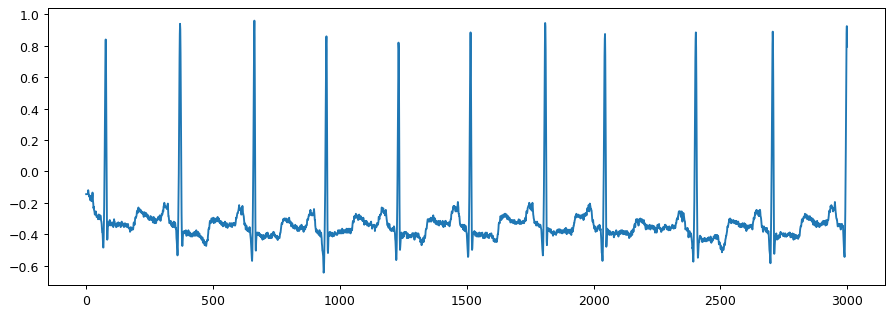

In [ ]:
# ECG signal per second

a = lead0[patient_id][0: 3000]
plt.figure(figsize=(12, 4), dpi=90)
plt.plot(a)

In [82]:
# Loading all patients ECG SIGNALs using for loop

def get_ecg_signals(patient_ids):
    lead0 = {}
    lead1 = {}

    for id_ in patient_ids:
        record_path = osj(DATA_ROOT, str(id_))

        if not os.path.exists(record_path + ".hea"):
            continue

        signals, info = wfdb.rdsamp(record_path)
        lead0[id_] = signals[:, 0]
        lead1[id_] = signals[:, 1]

    return lead0, lead1

In [83]:
# Loading all patient ECG INFORMATION 

def get_ecg_info(patient_ids):
    info_dict = {}

    for id_ in patient_ids:
        record_path = osj(DATA_ROOT, str(id_))
        if not os.path.exists(record_path + ".hea"):
            continue

        _, info = wfdb.rdsamp(record_path)
        info["resolution"] = 2**11
        info_dict[id_] = info

    return info_dict

In [85]:
lead0, lead1 = get_ecg_signals(patient_ids)
info = get_ecg_info(patient_ids)

print("Jumlah pasien:", len(lead0))

Jumlah pasien: 48


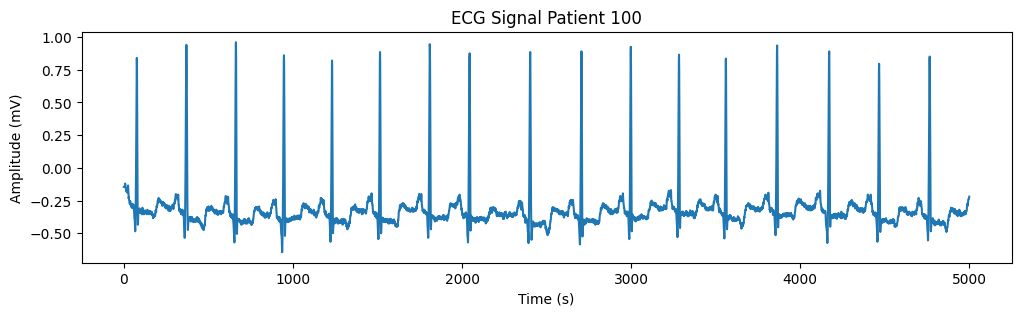

In [94]:
# Plot any patient signal from any time frame
sample_id = patient_ids[0]


plt.figure(figsize=(12, 3), dpi=100)
plt.plot(lead0[sample_id][:5000])
plt.title(f"ECG Signal Patient {sample_id}")
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.show()

In [106]:
def get_single_ecg_info(patient_id):
    record_path = osj(DATA_ROOT, str(patient_id))
    _, info = wfdb.rdsamp(record_path)
    
    info["resolution"] = 2**11
    return info

ecg_info = get_single_ecg_info(patient_ids[0])
print(ecg_info)

{'fs': 360, 'sig_len': 650000, 'n_sig': 2, 'base_date': None, 'base_time': None, 'units': ['mV', 'mV'], 'sig_name': ['MLII', 'V5'], 'comments': ['69 M 1085 1629 x1', 'Aldomet, Inderal'], 'resolution': 2048}


## **Part 2: Denoising, R-Peak Detection, Segmentation**

### **Part 2.1 : Signal Denoising**
Denoising menggunakan Discrete Wavelet Transform (DWT)

In [107]:
# User defined fucntion for DWT and reconstruction
def denoise(data):
    # wavelet transform
    coeffs = pywt.wavedec(data=data, wavelet='db5', level=9)
    cA9, cD9, cD8, cD7, cD6, cD5, cD4, cD3, cD2, cD1 = coeffs

    # Threshold denoising
    threshold = (np.median(np.abs(cD1)) / 0.6745) * (np.sqrt(2 * np.log(len(cD1))))
    cD1.fill(0)
    cD2.fill(0)
    for i in range(1, len(coeffs) - 2):
        coeffs[i] = pywt.threshold(coeffs[i], threshold)

    # Inverse wavelet transform to obtain the denoised signal
    rdata = pywt.waverec(coeffs=coeffs, wavelet='db5')
    return rdata

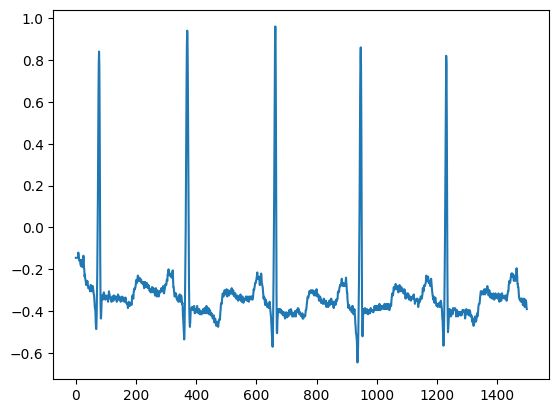

In [113]:
# Ploting a signal before denoising
sample_id = patient_ids[0]
record = wfdb.rdrecord(osj(DATA_ROOT, str(sample_id)), channel_names=['MLII'])
data = record.p_signal.flatten()
plt.plot(data[0:1500])

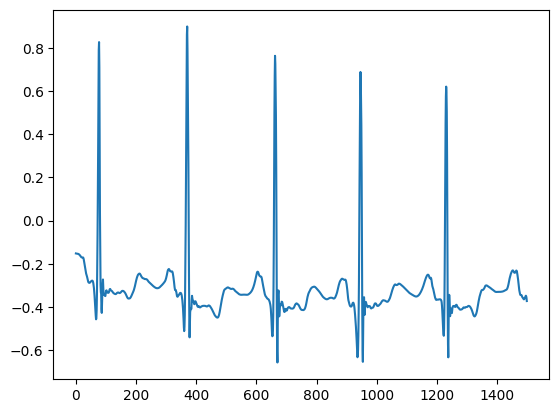

In [114]:
# Same signal after denoising
rdata = denoise(data=data)
plt.plot(rdata[0:1500])

### **Part 2.2 : Signal R-Peak Detection**
R-peak sudah dianotasi/dilabel dalam dataset MIT-BIH.

In [115]:
sample_id = patient_ids[0]
annotation = wfdb.rdann(osj(DATA_ROOT, str(sample_id)), 'atr')
Rlocation = annotation.sample
Rclass = annotation.symbol
print("R locations:", Rlocation[:10])
print("R classes:", Rclass[:10])

R locations: [  18   77  370  662  946 1231 1515 1809 2044 2402]
R classes: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']


In [116]:
len(annotation.symbol)

2274

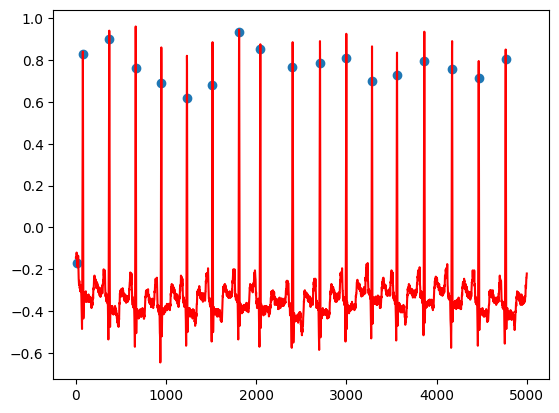

In [124]:
# R-peak ploting
x = np.arange(1, 5001)

n_peak = 18
r_peak_x = []
r_peak_y = []
for i in range(0, n_peak):
  r_peak_x.append(Rlocation[i])
  r_peak_y.append(rdata[Rlocation[i]])

plt.plot(x, data[0:5000], color='red')
plt.scatter(r_peak_x, r_peak_y)

### **Part 2.3 : Signal Segmentation**
"Sinyal EKG disegmentasi menggunakan window length 300 sampel, dari R-peak, 99 sampel dari sisi kiri dan 201 sampel dari sisi kanan. Satu siklus detak jantung (heartbeat) yang lengkap dapat diperoleh.

(300,)
(300,)
(300,)


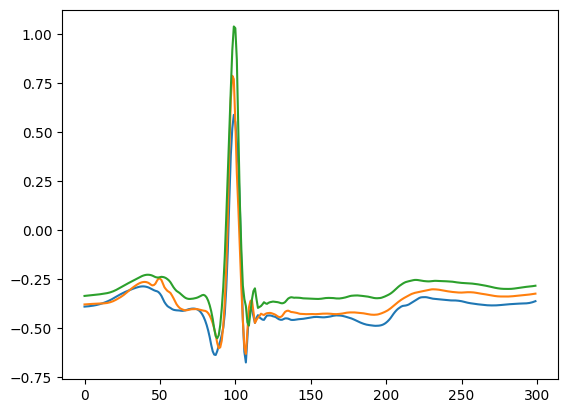

In [ ]:
# Plotting 3 heartbeats

k = np.arange(100, 103)
for i in k:
  x_train = rdata[Rlocation[i] - 99:Rlocation[i] + 201]
  plt.plot(x_train)
  print(x_train.shape)
plt.show()

### **Part 2.4 : Complete the Processing**
Tahapan pra-pemrosesan, denoising, deteksi R-peak, dan segmentasi ditampilkan dalam satu gambar tunggal.

In [130]:
r_peak_xx = Rlocation[0], Rlocation[1], Rlocation[2], Rlocation[3]
r_peak_yy = rdata[Rlocation[0]], rdata[Rlocation[1]], rdata[Rlocation[2]], rdata[Rlocation[3]]

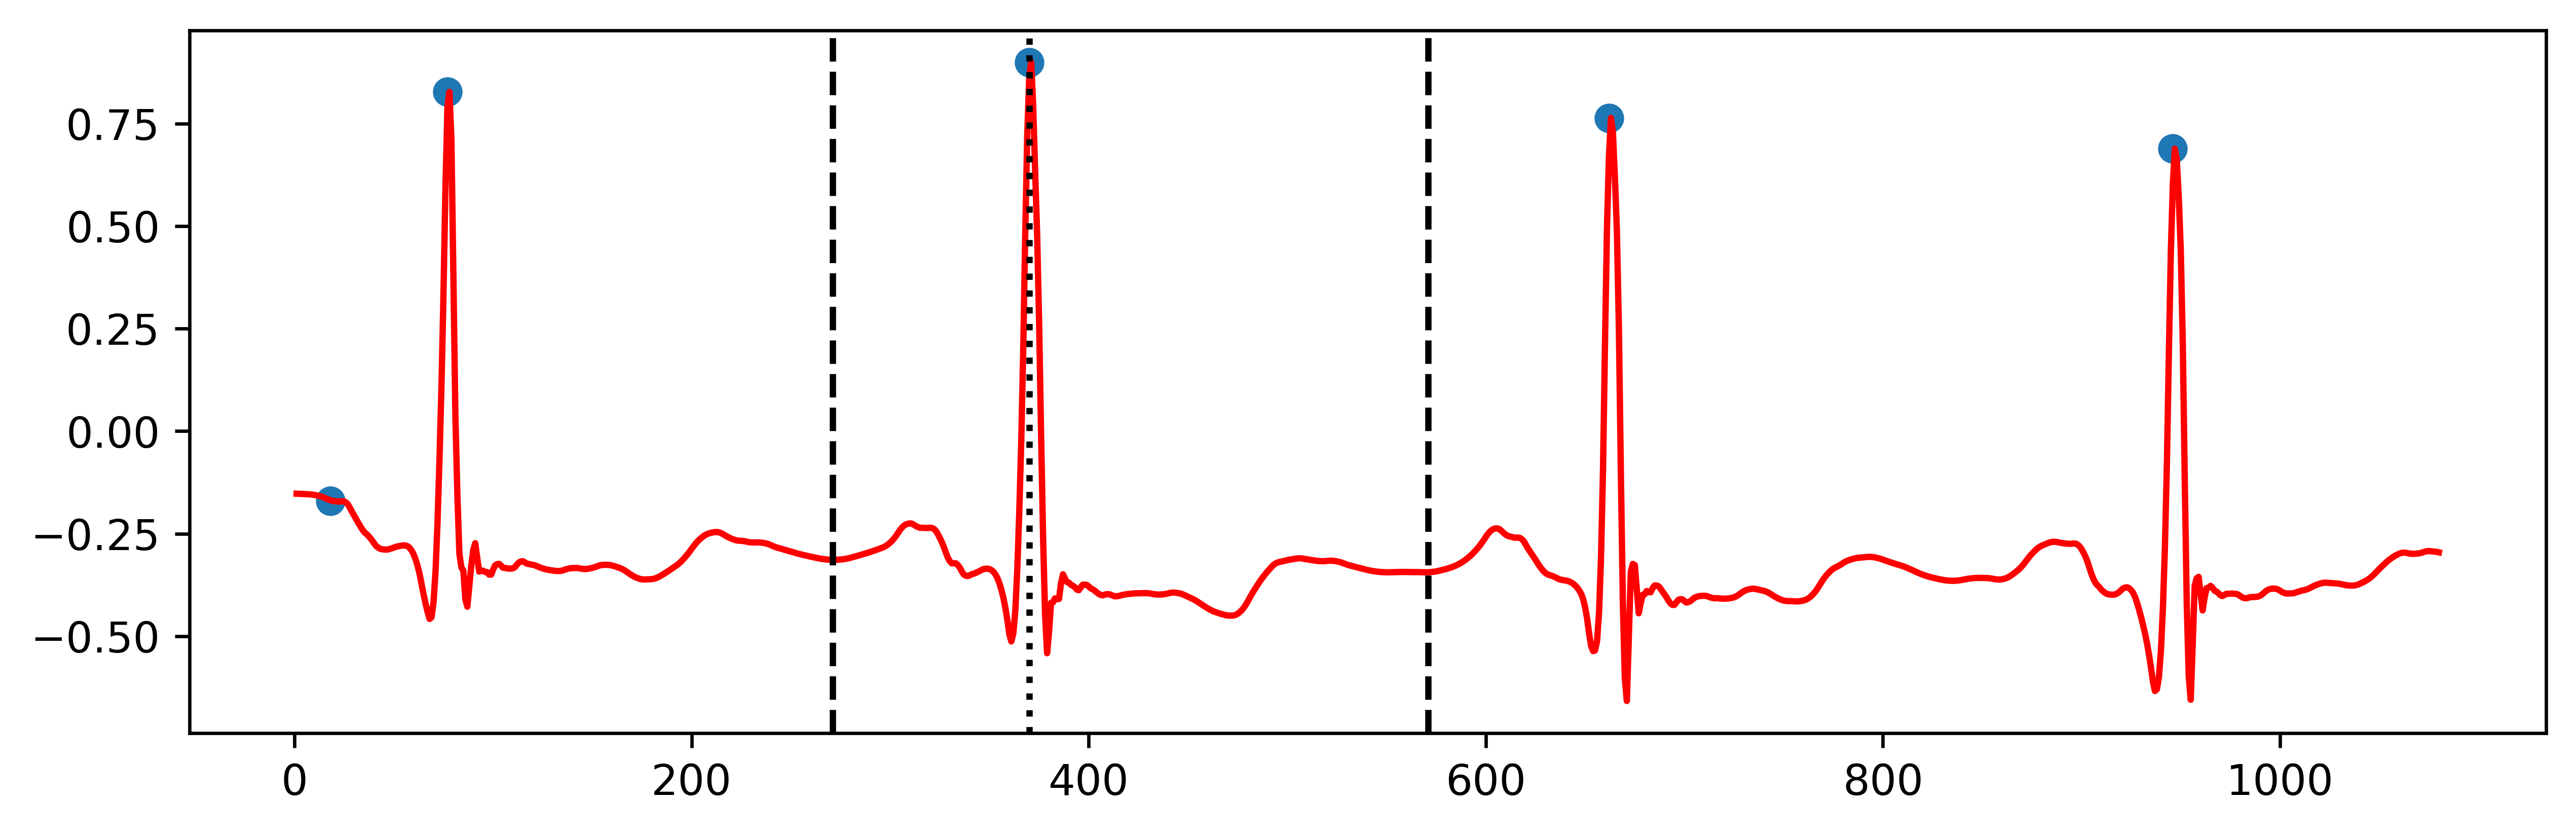

In [131]:
# Plotting R-peaks and segmentation lines
fig = plt.figure(figsize=(10,3), dpi=600)
n_peak =5
r_peak_x = []
r_peak_y = []
for i in range(0, n_peak):
  r_peak_x.append(Rlocation[i])
  r_peak_y.append(rdata[Rlocation[i]])
x = np.arange(1, 1081)
plt.plot(x, rdata[0: 1080], color='red')
plt.scatter(r_peak_x, r_peak_y)

# line plotting
plt.axvline(x = Rlocation[2], color = 'k', linestyle = ':') 
plt.axvline(x = Rlocation[2]-99, color = 'k', linestyle = '--') 
plt.axvline(x = Rlocation[2]+201, color = 'k', linestyle = '--') 

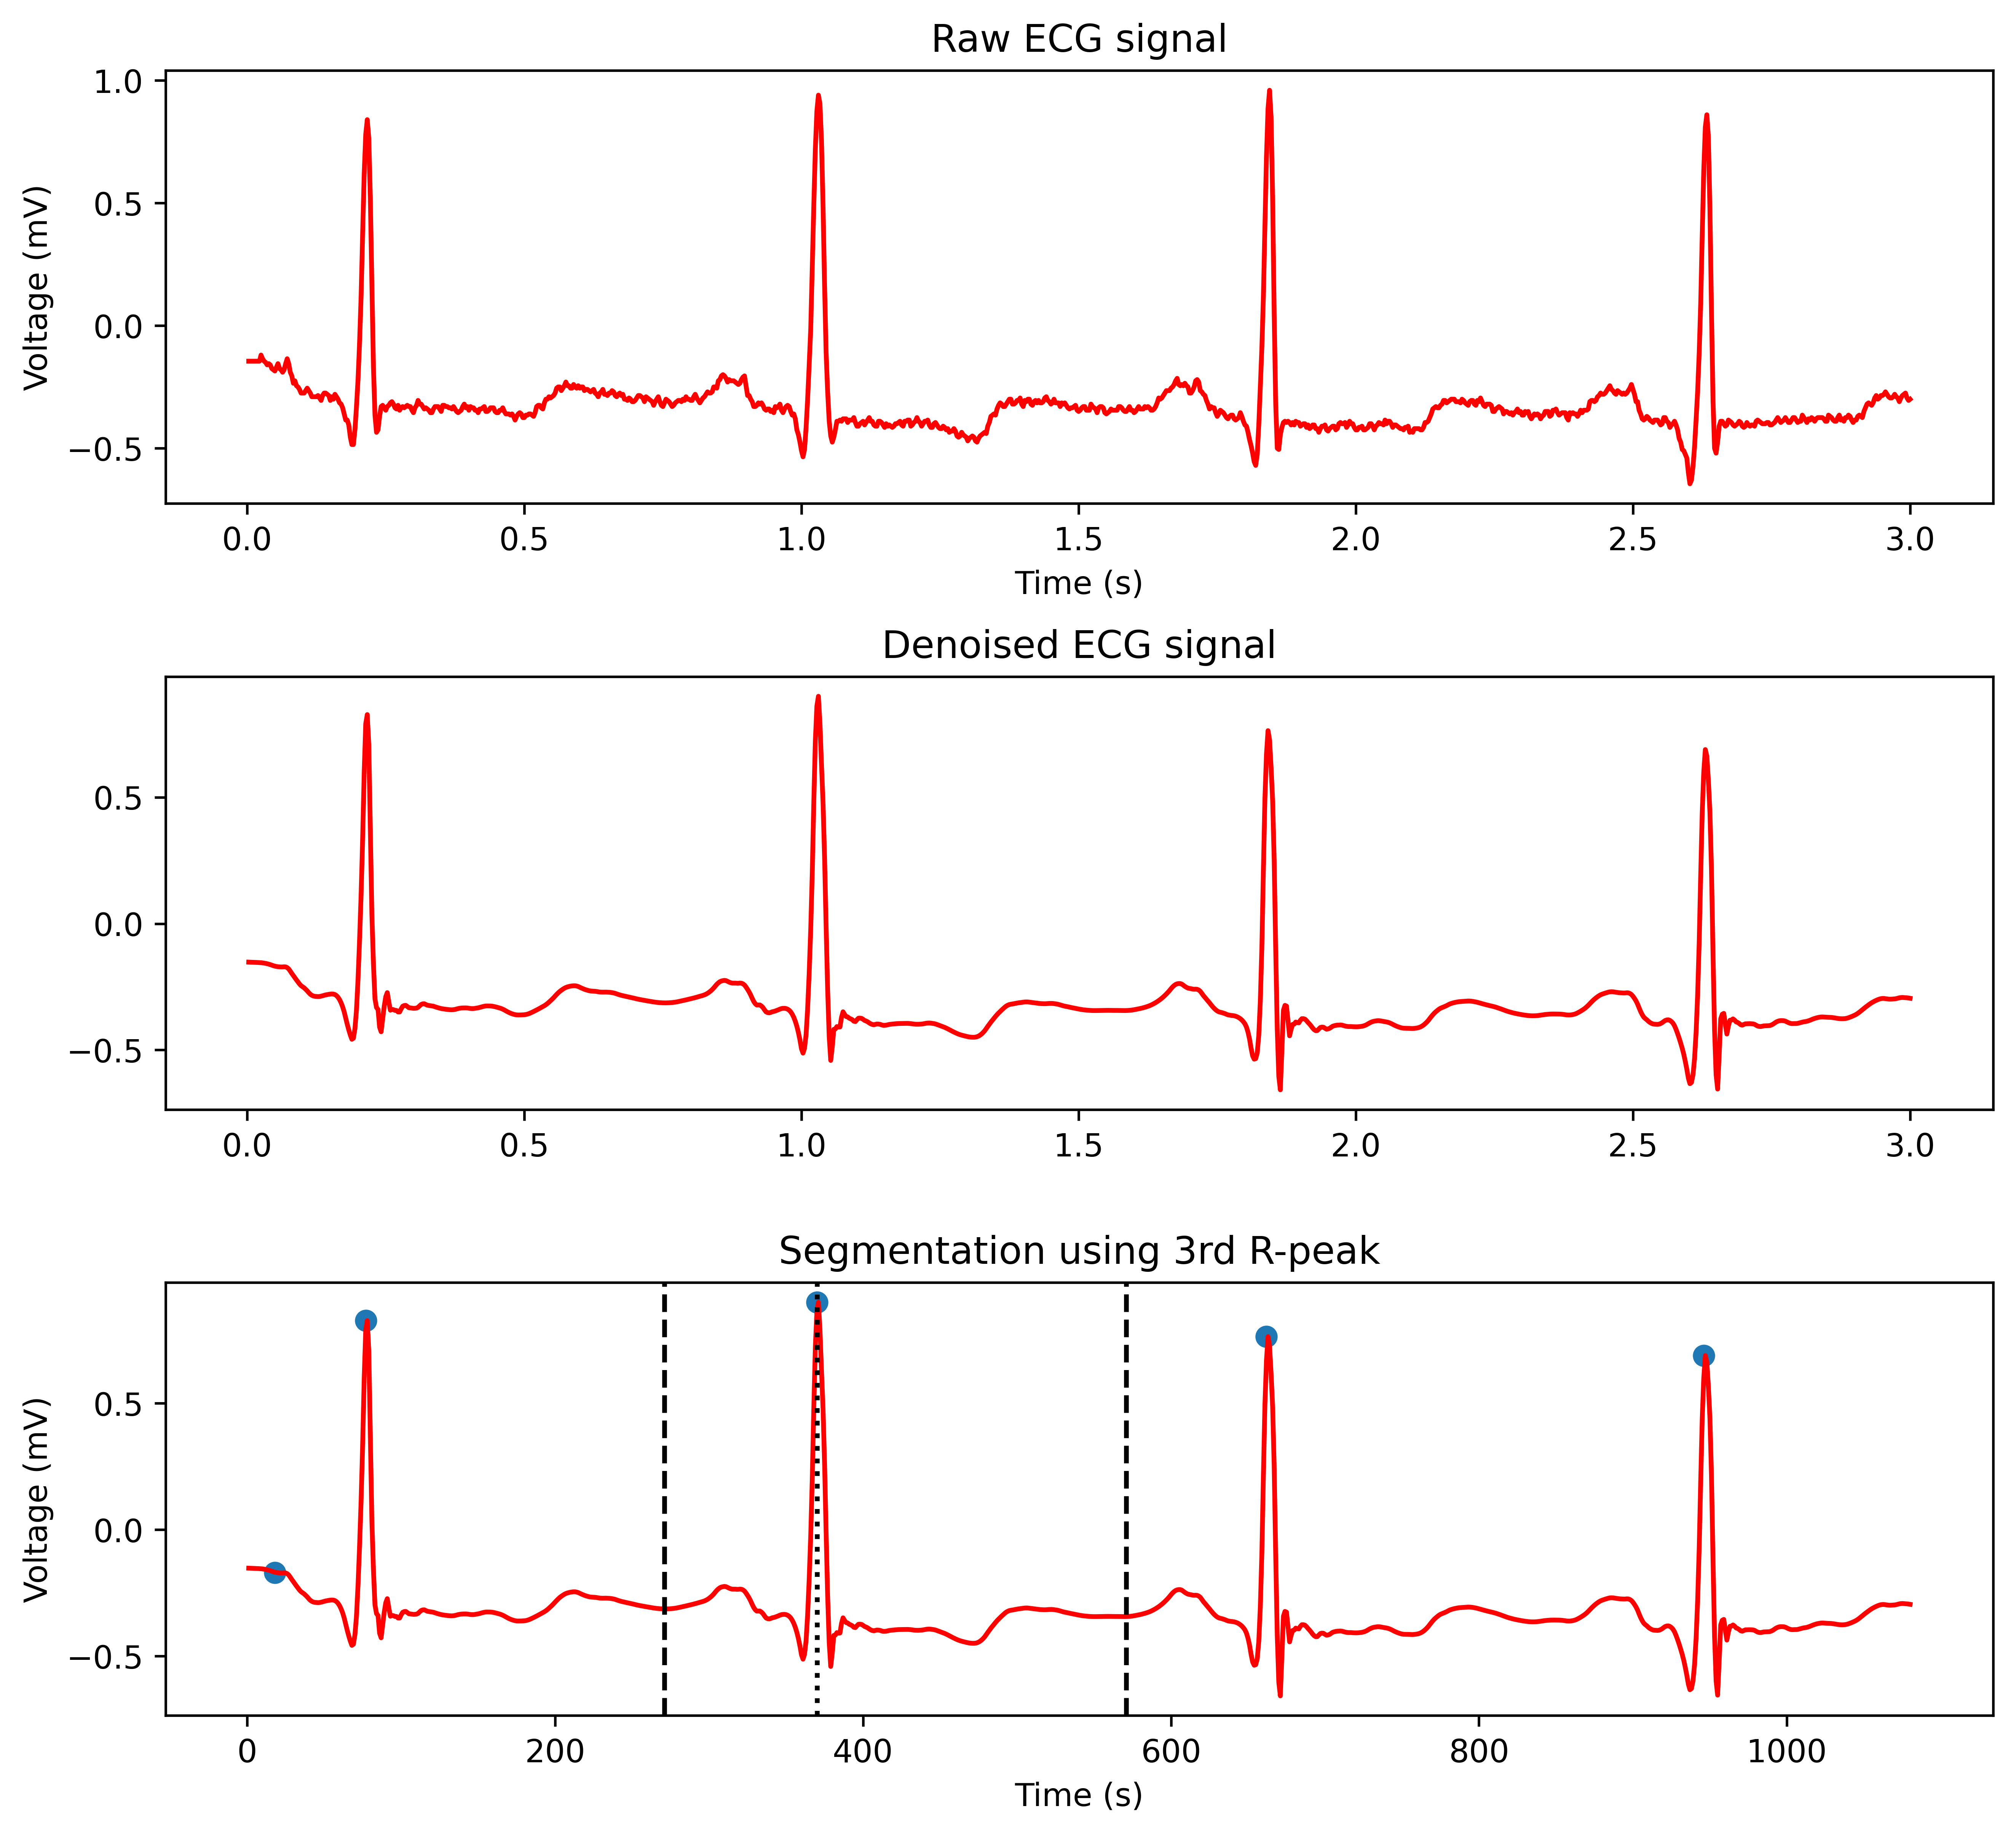

In [132]:
# Plot together raw, denoised and segmted signal
fig = plt.figure(figsize=(10,9), dpi=600)
x = np.arange(1, 1081)

# Raw signal plotting
plt.subplot(3, 1, 1)
plt.plot(x/360, data[0:1080], color='red')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.title('Raw ECG signal')

# Denoised signal plotting
plt.subplot(3, 1, 2)
plt.plot(x/360, rdata[0:1080], color='red')
plt.title('Denoised ECG signal')

# Segmentation visualization using two border lines
plt.subplot(3, 1, 3)
n_peak =5
r_peak_x = []
r_peak_y = []
for i in range(0, n_peak):
  r_peak_x.append(Rlocation[i])
  r_peak_y.append(rdata[Rlocation[i]])
x = np.arange(1, 1081)
plt.plot(x, rdata[0: 1080], color='red')
plt.scatter(r_peak_x, r_peak_y)
# line plotting
plt.axvline(x = Rlocation[2], color = 'k', linestyle = ':') # 3rd r-peak
plt.axvline(x = Rlocation[2]-99, color = 'k', linestyle = '--') 
plt.axvline(x = Rlocation[2]+201, color = 'k', linestyle = '--')

plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.title('Segmentation using 3rd R-peak')

plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.4)

## **Part 3: Loading Dataset**


### **Part 3.1 : Loading All Dataset from 'project_path'**

In [ ]:
def getDataSet(number, X_data, Y_data):
    
    # Considering 15 types ECG heartbeats that are later grouped in 5 classes
    ecgClassSet = ['N', 'L', 'R', 'e', 'j', 'A', 'a', 'J', 'S', 'V', 'E', 'F', '/', 'f', 'Q'] 

    record_path = osj(project_path, number)

    # Reading Channel names
    _, info = wfdb.io.rdsamp(record_path)
    channels = info['sig_name']
    channel1, channel2 = channels[0], channels[1]
    print(channel1, channel2)
    
    # Read ECG data records
    print("reading " + number + " ECG data...")
    record = wfdb.rdrecord(record_path, channel_names=[channel1])
    data = record.p_signal.flatten()
    rdata = denoise(data=data)

    # Obtain the position and corresponding label of the R wave in the ECG data record
    annotation = wfdb.rdann(record_path, 'atr')
    Rlocation = annotation.sample
    Rclass = annotation.symbol

    # Unstable data before and after removal
    start = 2
    end = 3  
    i = start
    j = len(annotation.symbol) - end

    # Making labels, Y_data Convert NSVFQ in order to 0123456...14
    while i < j:
        try:
            beat_type = Rclass[i]
            lable = ecgClassSet.index(beat_type)

            if Rlocation[i] - 99 >= 0 and Rlocation[i] + 201 < len(rdata):
                x_train = rdata[Rlocation[i] - 99:Rlocation[i] + 201]
                X_data.append(x_train)
                Y_data.append(lable)

            i += 1

        except ValueError:
            i += 1

    return X_data, Y_data

In [154]:
# Load the dataset and preprocess it
def loadData():
    numberSet = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
                 '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', 
                 '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', 
                 '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', 
                 '222', '223', '228', '230', '231', '232', '233', '234'] # 48 readings
    dataSet = []
    lableSet = []
    for n in numberSet:
        # getDataSet(n, dataSet, lableSet)
        dataSet, lableSet = getDataSet(n, dataSet, lableSet)

    # Turn numpy array, scramble the order
    dataSet = np.array(dataSet).reshape(-1, 300)
    lableSet = np.array(lableSet).reshape(-1, 1)
    train_ds = np.hstack((dataSet, lableSet))
    np.random.shuffle(train_ds)

    # dataset and its label set
    X = train_ds[:, :300]
    Y = train_ds[:, 300]
    return X, Y

In [145]:
# Input X and Output Y data loading
X, Y = loadData()

MLII V5
reading 100 ECG data...
MLII V1
reading 101 ECG data...
V5 V2
reading 102 ECG data...
MLII V2
reading 103 ECG data...
V5 V2
reading 104 ECG data...
MLII V1
reading 105 ECG data...
MLII V1
reading 106 ECG data...
MLII V1
reading 107 ECG data...
MLII V1
reading 108 ECG data...
MLII V1
reading 109 ECG data...
MLII V1
reading 111 ECG data...
MLII V1
reading 112 ECG data...
MLII V1
reading 113 ECG data...
V5 MLII
reading 114 ECG data...
MLII V1
reading 115 ECG data...
MLII V1
reading 116 ECG data...
MLII V2
reading 117 ECG data...
MLII V1
reading 118 ECG data...
MLII V1
reading 119 ECG data...
MLII V1
reading 121 ECG data...
MLII V1
reading 122 ECG data...
MLII V5
reading 123 ECG data...
MLII V4
reading 124 ECG data...
MLII V1
reading 200 ECG data...
MLII V1
reading 201 ECG data...
MLII V1
reading 202 ECG data...
MLII V1
reading 203 ECG data...
MLII V1
reading 205 ECG data...
MLII V1
reading 207 ECG data...
MLII V1
reading 208 ECG data...
MLII V1
reading 209 ECG data...
MLII V1
read

In [146]:
from collections import Counter

# Counting the number of each type of heartbeats
Y_list = list(Y)
Counter(Y_list)

Counter({np.float64(0.0): 74920,
         np.float64(1.0): 8063,
         np.float64(2.0): 7244,
         np.float64(9.0): 7123,
         np.float64(12.0): 7012,
         np.float64(5.0): 2540,
         np.float64(13.0): 982,
         np.float64(11.0): 802,
         np.float64(4.0): 229,
         np.float64(6.0): 150,
         np.float64(10.0): 106,
         np.float64(7.0): 83,
         np.float64(14.0): 33,
         np.float64(3.0): 16,
         np.float64(8.0): 2})

### **Part 3.2 : Plotting the 15 Different Heartbeats**
Plot 15 jenis aritmia (label jenis aritmia harus diberikan dalam dataset)

In [147]:
# making pandas dataframe
df_X = pd.DataFrame(X)
df_Y = pd.DataFrame(Y)

In [148]:
# changing the name from 0 to 300
df_Y.rename(columns = {0:300}, inplace = True)
# join X and Y
df = pd.concat([df_X, df_Y], axis=1)

In [149]:
def Plot_Random_Beat(type, num):

  ecgClassSet = ['N', 'L', 'R', 'e', 'j', 'A', 'a', 'J', 'S', 'V', 'E', 'F', 'slash', 'f', 'Q']
  
  ecgClassName = ['Normal (N)', 'Left bundle br. bl. (L)', 'Right bundle br. bl. (R)', 
                  'Atrial escape (e)', 'Nodal jun. esc. (j)', 'Atrial premature (A)', 
                  'Aberrated atrial prem. (a)', 'Nodal jun. pre. (J)', 
                  'Supraventricular prem. (S)', 'Premature ventr. (V)', 
                  'Ventricular escape (E)', 'Fusion of ve. & no. (F)', 
                  'Paced (/)', 'Fusion of pa. & no. (f)', 
                  'Unclassifiable(Q)'] 

  # getting only a specific class ECG signal
  df_0 = df.loc[df[300]==type]  # For normanl class: 0, shape is 74920,301
  df_0 = df_0.drop(columns=[300]) # changing the shape to 74920,300

  # selecting some random row to plot
  if num<=df_0.shape[0]:
    np.random.seed(234)
    random_beat_number = np.random.randint(df_0.shape[0], size=(num))
    random_beat_number = list(random_beat_number)
  else: # Needed for Supraventricular Premature Beat (S) only, as it contains only 2 beats
    print(f"Warning: You have only {df_0.shape[0]} beat, but asked to plot {num}")
    random_beat_number = np.arange(0, df_0.shape[0])
    random_beat_number = list(random_beat_number)
  
  # ploting the ECG signal
  for i in random_beat_number:
    ecg_beat = df_0.iloc[i]
    plt.plot(ecg_beat)
  plt.title(str(ecgClassName[type]))

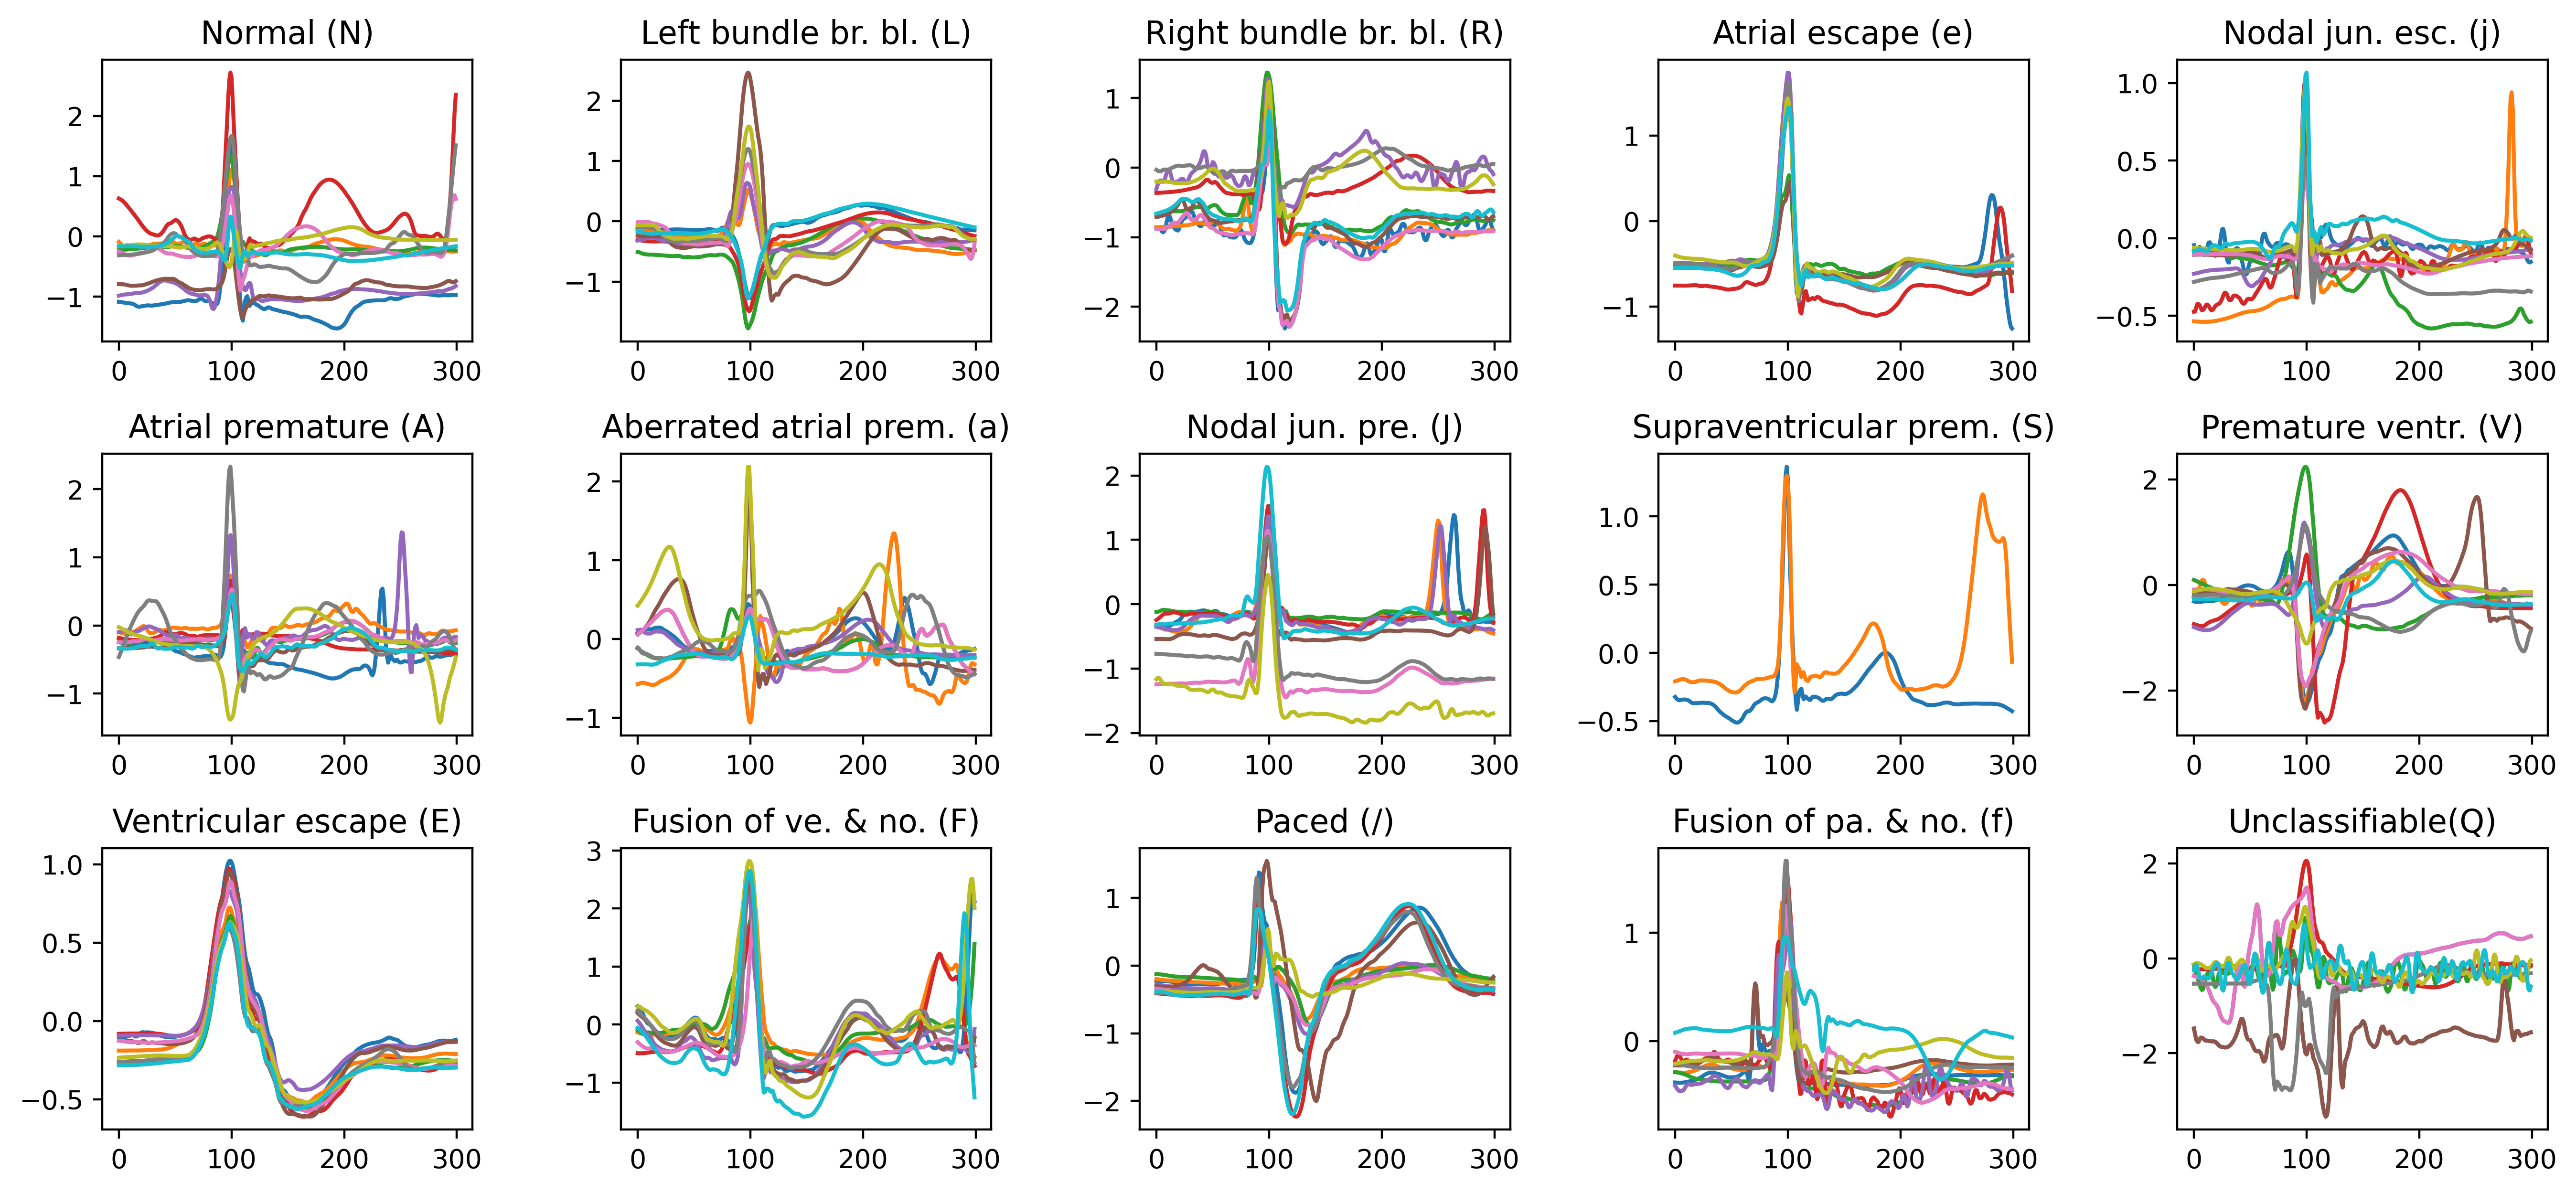

In [183]:
# Plotting 15 different types of heartbeat
fig = plt.figure(figsize=(16,7), dpi=400)
fig.tight_layout(pad=15.0)
for i in range(15):
  plt.subplot(3,5,i+1)
  plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.4)
  Plot_Random_Beat(type=i, num=10)
  
figure_path = '/Users/alstanlin/Desktop/CAT-NET for Arrhythmia Detection/'
fig.savefig(figure_path + 'all_heartbeats.png')

# **Part 4: Train-Test Splitting and Class Balancing**

### **Part 4.1 : 15 Types of Heartbeats to 5 Level Conversion**
Konversi seluruh 15 jenis aritmia menjadi 5 garis besar (sesuai dengan penjelasan di awal kode)

In [157]:
train_ds = loadData()

MLII V5
reading 100 ECG data...
MLII V1
reading 101 ECG data...
V5 V2
reading 102 ECG data...
MLII V2
reading 103 ECG data...
V5 V2
reading 104 ECG data...
MLII V1
reading 105 ECG data...
MLII V1
reading 106 ECG data...
MLII V1
reading 107 ECG data...
MLII V1
reading 108 ECG data...
MLII V1
reading 109 ECG data...
MLII V1
reading 111 ECG data...
MLII V1
reading 112 ECG data...
MLII V1
reading 113 ECG data...
V5 MLII
reading 114 ECG data...
MLII V1
reading 115 ECG data...
MLII V1
reading 116 ECG data...
MLII V2
reading 117 ECG data...
MLII V1
reading 118 ECG data...
MLII V1
reading 119 ECG data...
MLII V1
reading 121 ECG data...
MLII V1
reading 122 ECG data...
MLII V5
reading 123 ECG data...
MLII V4
reading 124 ECG data...
MLII V1
reading 200 ECG data...
MLII V1
reading 201 ECG data...
MLII V1
reading 202 ECG data...
MLII V1
reading 203 ECG data...
MLII V1
reading 205 ECG data...
MLII V1
reading 207 ECG data...
MLII V1
reading 208 ECG data...
MLII V1
reading 209 ECG data...
MLII V1
read

In [158]:
Y = train_ds[:, 300]

In [159]:
# 15 level to 5 level conversion
Y_5class = np.copy(Y)

for i in range(Y.shape[0]):
  # print(i)
  if 0 <= Y[i] <= 4:
    Y_5class[i] = 0
  if 5 <= Y[i] <= 8:
    Y_5class[i] = 1
  if 9 <= Y[i] <= 10:
    Y_5class[i] = 2
  if Y[i] == 11:
    Y_5class[i] = 3
  if 12 <= Y[i] <= 14:
    Y_5class[i] = 4
print('changing done')

changing done


In [160]:
Y_5class_list = list(Y_5class)
Counter(Y_5class_list)

Counter({np.float64(0.0): 90472,
         np.float64(4.0): 8027,
         np.float64(2.0): 7229,
         np.float64(1.0): 2775,
         np.float64(3.0): 802})

In [161]:
ecg_dataset = np.copy(train_ds)

In [ ]:
# label encode the target variable 
# just convert numpy.float64 to numpy.int64
from sklearn.preprocessing import LabelEncoder
Y_5class = LabelEncoder().fit_transform(Y_5class)

In [164]:
ecg_data = ecg_dataset[:, :300]
ecg_lable = Y_5class.reshape(-1, 1) # otherwise np.hstack will not work 

In [165]:
# Complete ECG dataset with 5 type of Arrhythmia
ecg_dataset_5 = np.hstack((ecg_data, ecg_lable))

In [166]:
# Convert ndarray to dataframe
df_ecg = pd.DataFrame(ecg_dataset_5)
class_data = df_ecg[300].value_counts()
class_data

300
0.0    90472
4.0     8027
2.0     7229
1.0     2775
3.0      802
Name: count, dtype: int64

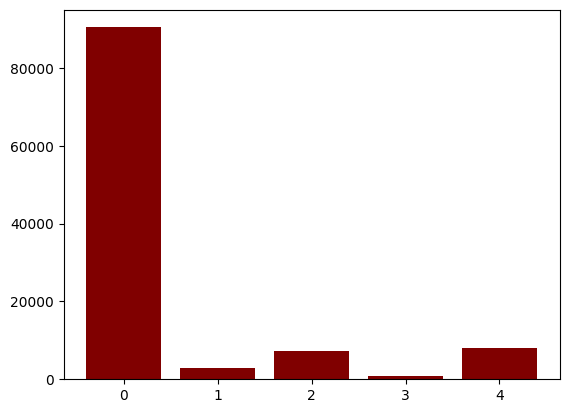

In [167]:
# per class data status plotting,
plt.bar(class_data.index, class_data.values, color ='maroon')
plt.show()

### **Part 4.2 : Data Training-Testing Splitting**
Catatan: Class Balance hanya boleh dilakukan pada Training Data, bukan pada Testing Data.

In [168]:
# train test splitting
from sklearn.model_selection import train_test_split
ecg_data = ecg_dataset_5[:, :300]
ecg_label = ecg_dataset_5[:, 300]
x_train, x_test, y_train, y_test = train_test_split(ecg_data, ecg_label,
                                   random_state=104, 
                                   test_size=0.20, 
                                   shuffle=True)

In [169]:
# reshaping for using hstack function
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)
train_data = np.hstack((x_train, y_train))
test_data = np.hstack((x_test, y_test))

In [170]:
#  converting dataframe
train_data = pd.DataFrame(train_data)
test_data = pd.DataFrame(test_data)

In [171]:
# saving the test data (in imbalanced condition)
file_name = project_path + 'test_data.pkl'
test_data.to_pickle(file_name)

300
0.0    72396
4.0     6421
2.0     5773
1.0     2223
3.0      631
Name: count, dtype: int64


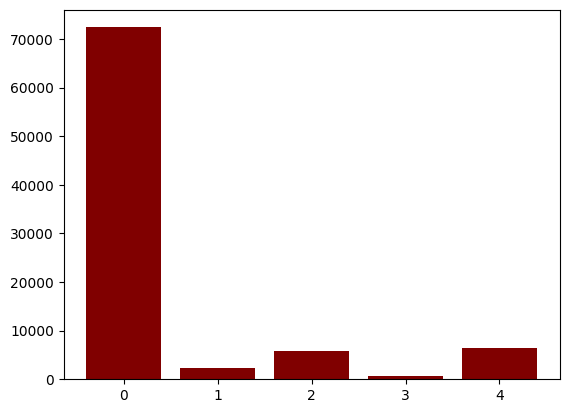

In [172]:
# Imblanced training data graph ploting 
class_data = train_data[300].value_counts()
print(class_data)
plt.bar(class_data.index, class_data.values, color ='maroon')
plt.show()

### **Part 4.3 : Class Balancing by Undersampling and SMOTE**
SMOTE singkatan dari 'Synthetic Minority Oversampling Technique'.
Rencana untuk Train Data:
1. Kelas 0: Pilih 50.000 data secara acak.
2. Kelas 1, 2, 3, 4: Gunakan SMOTE untuk melakukan oversampling hingga mencapai 50.000 data.

In [175]:
# extracting class 0 and 4 others class
train_data_0 = train_data.loc[(train_data[300] == 0)]
train_data_1234 = train_data.loc[(train_data[300] != 0)]

In [176]:
# 1. Class 1: Randomly selected 50000 data
from sklearn.utils import resample
train_data_0_resampled=train_data_0.sample(n=50000,random_state=42)

# convert dataframe to numpy array
train_data_0_resampled = train_data_0_resampled.to_numpy()

In [179]:
# 2. Class 1, 2, 3, 4: Use SMOTE to oversample upto 50000 data

# converting from df to np ndarray
train_data_1234_arr = train_data_1234.to_numpy()
X_4cl, y_4cl = train_data_1234_arr[:, :-1], train_data_1234_arr[:, -1]

from imblearn.over_sampling import SMOTE
# transform the dataset
strategy = {1:50000, 2:50000, 3:50000, 4:50000}
oversample = SMOTE(sampling_strategy=strategy)
X, y = oversample.fit_resample(X_4cl, y_4cl)

y = y.reshape(-1, 1)
train_data_1234_resampled = np.hstack((X, y))

In [180]:
# Join the class 0 and 1234
train_data_resampled = np.vstack((train_data_0_resampled, train_data_1234_resampled))

# shuffle the data, needed for proper training
np.take(train_data_resampled,np.random.permutation(train_data_resampled.shape[0]),axis=0,out=train_data_resampled)

array([[-0.28722445, -0.28848494, -0.28968116, ..., -0.2676001 ,
        -0.27120236,  0.        ],
       [-0.30751179, -0.3057489 , -0.30397116, ...,  0.75158413,
         0.82591842,  0.        ],
       [-0.16800687, -0.17244045, -0.17732933, ..., -0.28988055,
        -0.28821461,  1.        ],
       ...,
       [-0.07768788, -0.0759095 , -0.07457754, ..., -0.13804258,
        -0.13573806,  0.        ],
       [-0.65170895, -0.66662218, -0.68198135, ..., -0.11181153,
        -0.0988044 ,  2.        ],
       [ 0.0824179 ,  0.05861659,  0.0314233 , ...,  1.74909868,
         1.61083942,  2.        ]], shape=(250000, 301))

300
0.0    50000
1.0    50000
2.0    50000
3.0    50000
4.0    50000
Name: count, dtype: int64


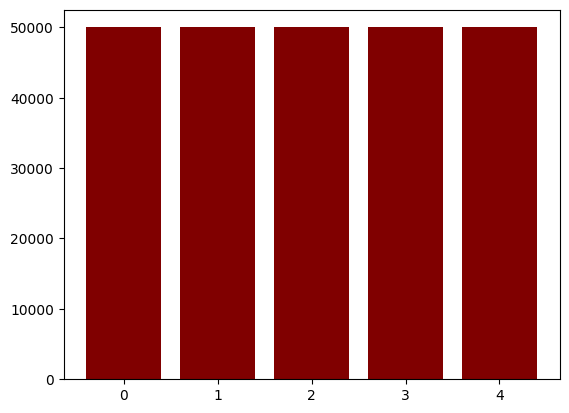

In [181]:
# blanced training data graph ploting 
train_data_r = pd.DataFrame(train_data_resampled)
class_data = train_data_r[300].value_counts()
print(class_data)
plt.bar(class_data.index, class_data.values, color ='maroon')
plt.show()

# save balanced training data
file_name = project_path + 'train_data_SMOTE.pkl'
train_data_r.to_pickle(file_name)

In [182]:
data_bal = np.array(class_data)
data_bal2 = data_bal.reshape(1, 5)

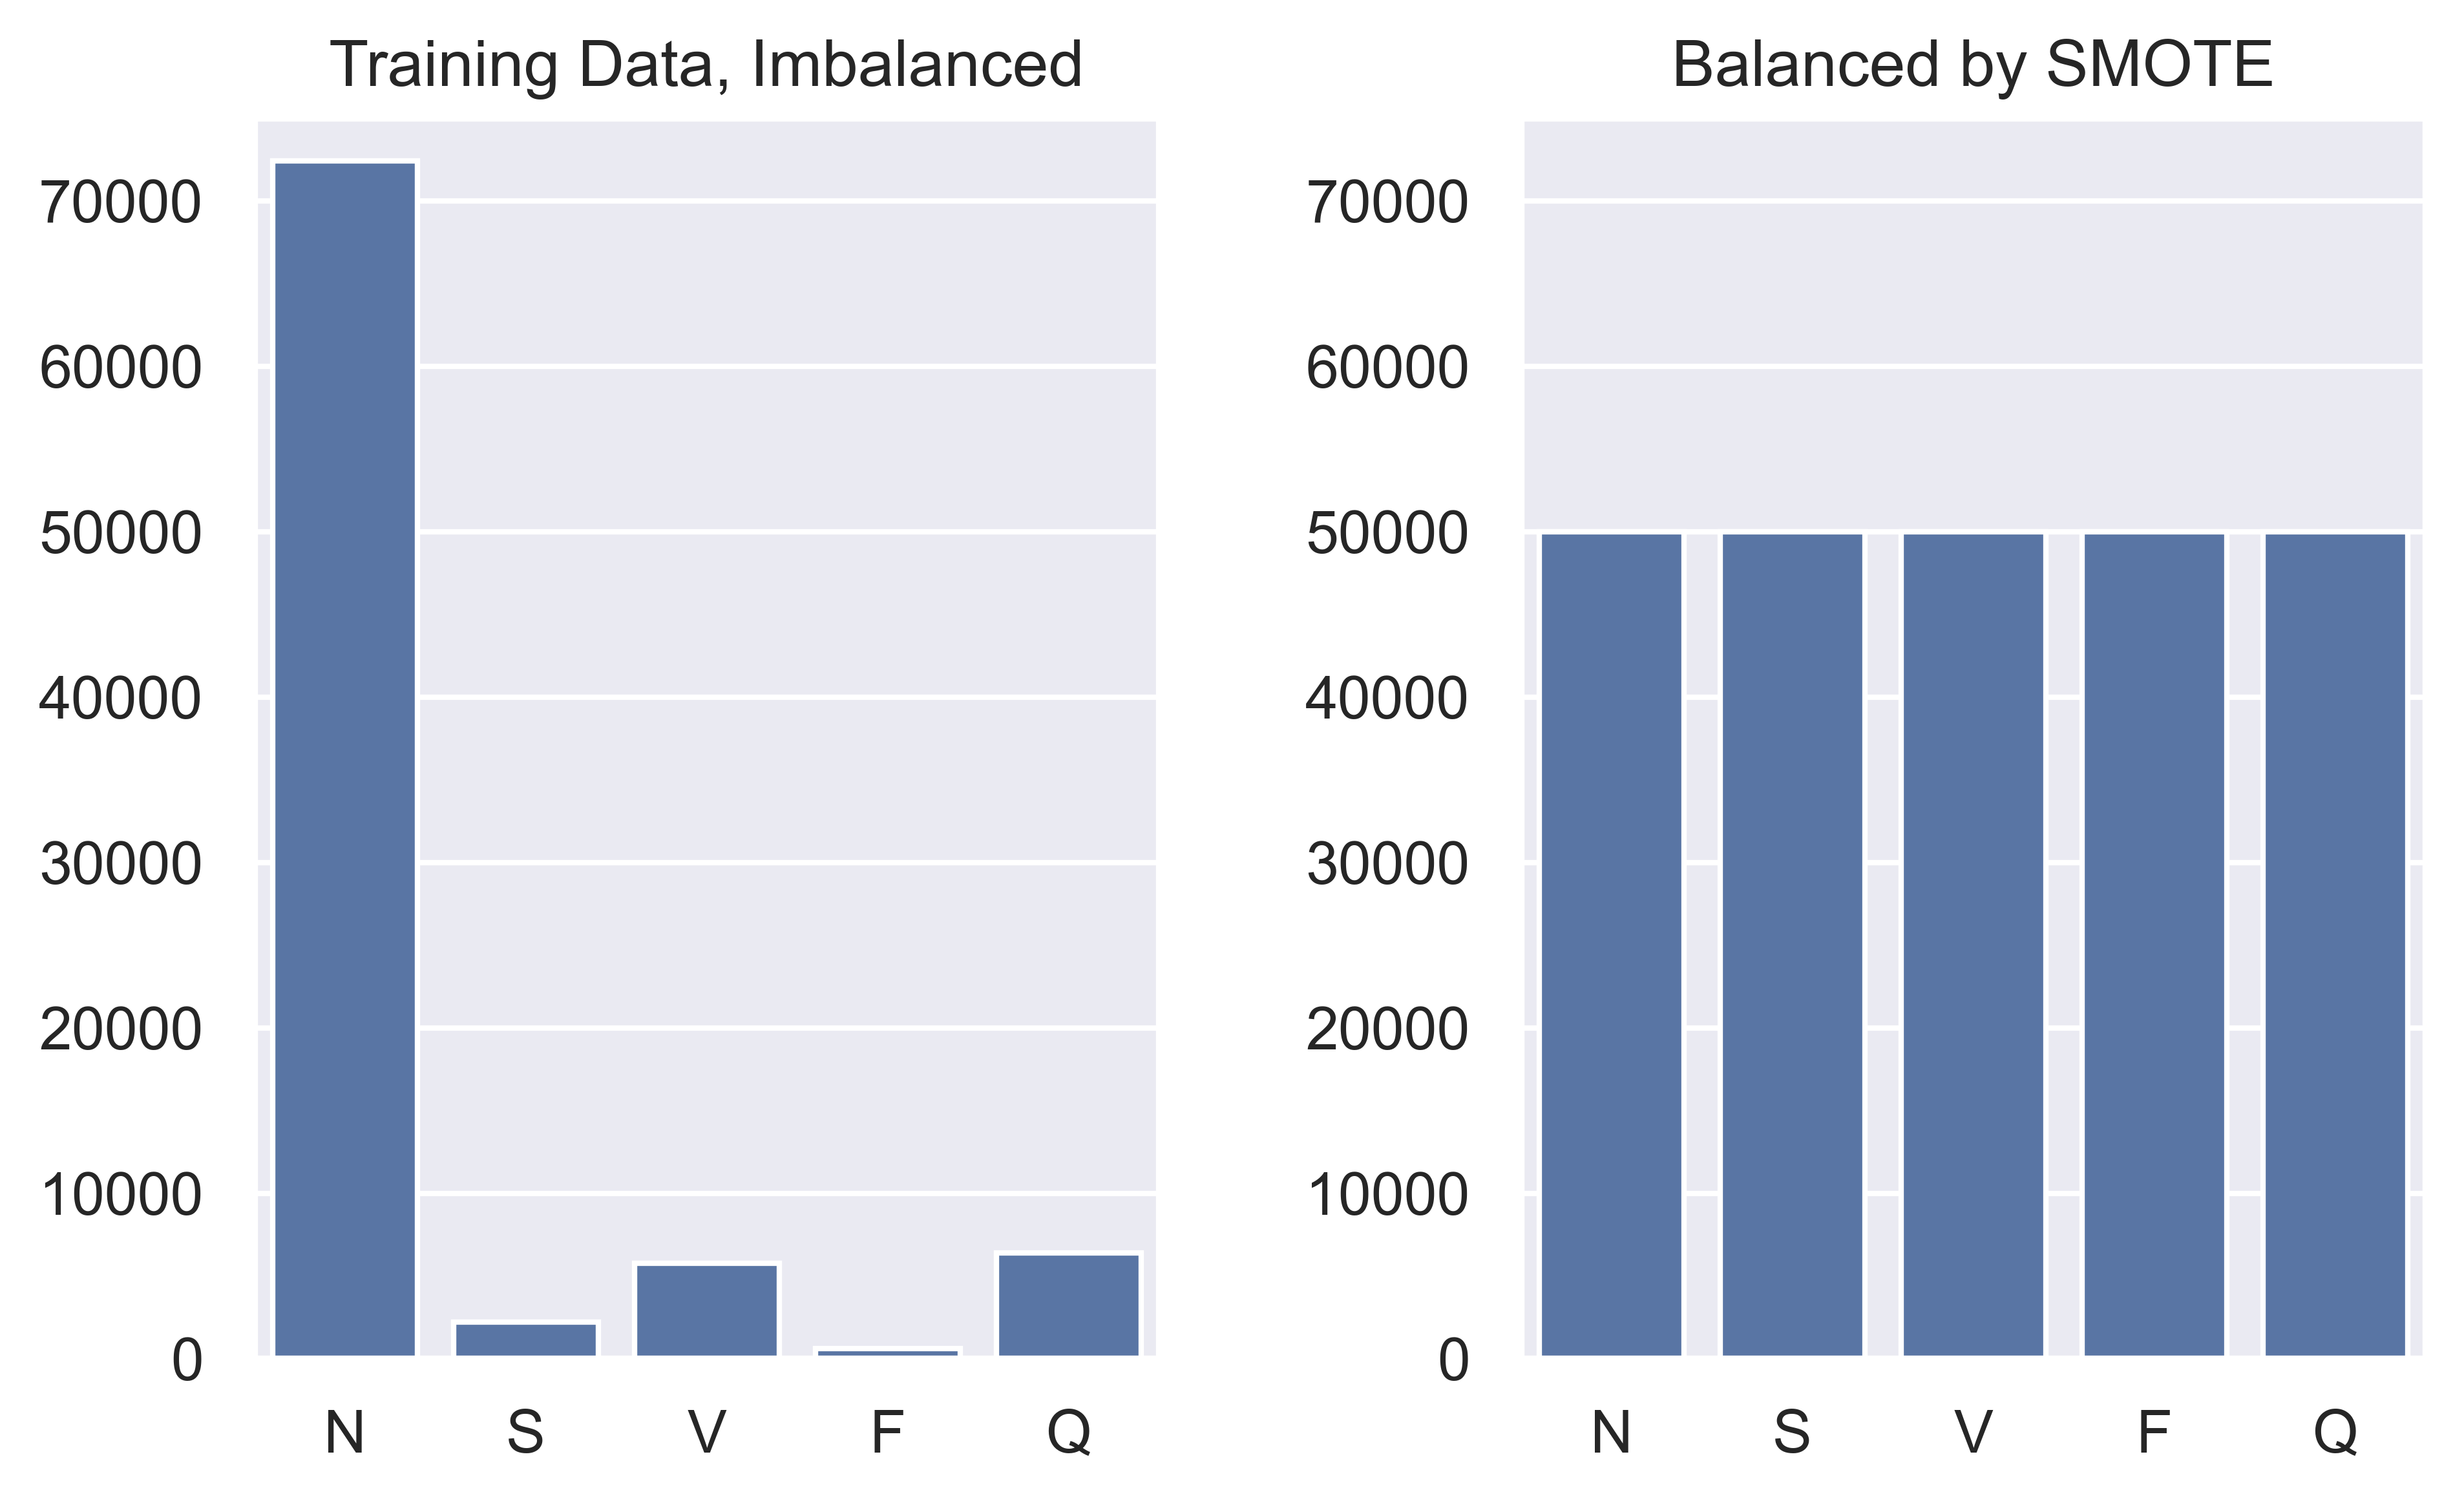

In [ ]:
# a single plot which gives proper illustration before and after class balancing
import seaborn as sns
sns.set()
sns.color_palette("hls", 8)

fig = plt.figure(figsize=(7,4), dpi=600)
plt.subplot(121)
sns.barplot(x = ['N', 'S', 'V', 'F', 'Q'], y = [72420, 2223, 5773, 631, 6421])
plt.ylim(0, 75000)
plt.title('Training Data, Imbalanced')

plt.subplot(122)
sns.barplot(x = ['N', 'S', 'V', 'F', 'Q'], y = class_data.values)
plt.ylim(0, 75000)
plt.title('Balanced by SMOTE')

plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.5)

figure_path = '/Users/alstanlin/Desktop/CAT-NET for Arrhythmia Detection/'
fig.savefig(figure_path + 'class_balancing.png')

## **Part 5: Model Building and Training**
**CNN-LSTM and Attention** based hybrid model is formulated. 

### **Part 5.1 : Attention Mechanism**
Convolutional Block Attention Module (CBAM) terdiri dari dua bagian:
1. Channel attention,
2. Spatial attention. 

Karena EKG yang digunakan dalam model ini adalah sinyal 1D dan hanya satu sadapan (1-lead), maka hanya channel attention (ML II) saja yang diterapkan.

In [192]:
# for channel attention mechanism
class ChannelAttention(tf.keras.layers.Layer):
    def __init__(self, filters, ratio=8):
        super(ChannelAttention, self).__init__()
        self.filters = filters
        self.ratio = ratio

    def build(self, input_shape):
        self.shared_layer_one = tf.keras.layers.Dense(
            self.filters // self.ratio,
            activation='relu',
            kernel_initializer='he_normal'
        )
        self.shared_layer_two = tf.keras.layers.Dense(
            self.filters,
            kernel_initializer='he_normal'
        )

    def call(self, inputs):
        # AvgPool
        avg_pool = tf.keras.layers.GlobalAveragePooling1D()(inputs)
        avg_pool = self.shared_layer_one(avg_pool)
        avg_pool = self.shared_layer_two(avg_pool)

        # MaxPool
        max_pool = tf.keras.layers.GlobalMaxPooling1D()(inputs)
        max_pool = self.shared_layer_one(max_pool)
        max_pool = self.shared_layer_two(max_pool)

        attention = tf.keras.layers.Add()([avg_pool, max_pool])
        attention = tf.keras.layers.Activation('sigmoid')(attention)

        attention = tf.keras.layers.Reshape((1, self.filters))(attention)

        return tf.keras.layers.Multiply()([inputs, attention])

In [193]:
# for spatial attention mechanism
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.kernel_size = kernel_size

    def build(self, input_shape):
        self.conv1d = tf.keras.layers.Conv1D(
            filters=1,
            kernel_size=self.kernel_size,
            padding='same',
            activation='sigmoid',
            kernel_initializer='he_normal',
            use_bias=False
        )
    def call(self, inputs):
        # AvgPool and MaxPool along the channel axis
        avg_pool = tf.reduce_mean(inputs, axis=2, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=2, keepdims=True)

        attention = tf.concat([avg_pool, max_pool], axis=2)
        attention = self.conv1d(attention)

        return inputs * attention

### **Part 5.2 : Making Transformer Encoder**
Transformer dirancang mengikuti arsitektur encoder. Masukannya adalah sinyal EKG setelah melewati convolution layers.

In [195]:
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Dropout, MultiHeadAttention, LayerNormalization, BatchNormalization, GlobalAveragePooling1D, Dense, Add, Flatten
from tensorflow.keras.models import Model

In [206]:
class TransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, num_heads, d_model, dff, dropout_rate):
        super(TransformerEncoder, self).__init__()

        self.multi_head_attention = tf.keras.layers.MultiHeadAttention(
            key_dim=d_model, num_heads=num_heads
        )

        self.dropout1 = tf.keras.layers.Dropout(dropout_rate)
        self.layer_norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dense1 = tf.keras.layers.Dense(dff, activation='relu')
        self.dense2 = tf.keras.layers.Dense(d_model)

        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)
        self.layer_norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

    def call(self, inputs, training=True):
        # Multi-head attention
        attn_output = self.multi_head_attention(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layer_norm1(inputs + attn_output)

        # Feed Forward Network 
        ffn_output = self.dense1(out1)
        ffn_output = self.dense2(ffn_output)
        ffn_output = self.dropout2(ffn_output, training=training)

        return self.layer_norm2(out1 + ffn_output)

In [207]:
def positional_encoding(seq_len, d, n=10000):
    P = np.zeros((seq_len, d))
    for k in range(seq_len):
        for i in np.arange(int(d/2)):
            denominator = np.power(n, 2*i/d)
            P[k, 2*i] = np.sin(k/denominator)
            P[k, 2*i+1] = np.cos(k/denominator)
    return tf.constant(P, dtype=tf.float32)

### **Part 5.3 : CNN-LSTM and Attention Model Architecture**

In [208]:
def buildModel():
    inputs = tf.keras.Input(shape=(300,1))

    # The first convolutional layer, 16 21x1 convolution kernels
    x = tf.keras.layers.Conv1D(16, 21, padding='same', activation='relu')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = ChannelAttention(16, 8)(x)
    # The first pooling layer, max pooling, 3x1 convolution kernels, stride 2
    x = tf.keras.layers.MaxPool1D(3, strides=2, padding='same')(x)

    # The second convolution layer, 32 23x1 convolution kernels
    x = tf.keras.layers.Conv1D(32, 23, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = ChannelAttention(32, 8)(x)
    # The second pooling layer, max pooling, 3x1 convolution kernels, with a stride of 2
    x = tf.keras.layers.MaxPool1D(3, strides=2, padding='same')(x)

    # The third convolution layer, 64 25x1 convolution kernels
    x = tf.keras.layers.Conv1D(64, 25, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = ChannelAttention(64, 8)(x)
    # The third pooling layer, average pooling, 3x1 convolution kernels, stride 2
    x = tf.keras.layers.AvgPool1D(3, strides=2, padding='same')(x)

    # The fourth convolution layer, 128 27x1 convolution kernels
    x = tf.keras.layers.Conv1D(128, 27, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)

    pos_enc = positional_encoding(seq_len=x.shape[1], d=x.shape[2])
    x = x + pos_enc

    # Transformer Encoder
    x = TransformerEncoder(
        num_heads=4,
        d_model=128,
        dff=256,
        dropout_rate=0.1
    )(x)

    # LSTM layer, 64 nodes
    x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=False))(x)
    
    # Dropout layer, dropout = 0.4
    x = tf.keras.layers.Dropout(rate=0.4)(x)

    # Fully connected layer, 128 nodes
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.4)(x)

    outputs = tf.keras.layers.Dense(5, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs)
    return model

### **Part 5.4 : Training the Model using Hyperparameter Tuning**

In [209]:
logdir = project_path + "logs\\" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
model_path = project_path + "ecg_model_code 17_t5.h5"

In [213]:
ratio = 0.2

if os.path.exists(model_path):
    print('Model already exists')
    model = tf.keras.models.load_model(
        model_path,
        custom_objects={
            'ChannelAttention': ChannelAttention,
            'SpatialAttention': SpatialAttention,
            'TransformerEncoder': TransformerEncoder
        }
    )
else:
    print('Model not found, building...')

    model = buildModel()

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        filepath=project_path + "weights.weights.h5",
        save_weights_only=True,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True
    )

    history = model.fit(
        x_train, y_train,
        epochs=30,
        batch_size=128,
        validation_split=ratio,
        callbacks=[tensorboard_callback, checkpoint_cb]
    )

    model.save(model_path)

Model not found, building...
Epoch 1/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 308s 547ms/step - accuracy: 0.9559 - loss: 0.1695 - val_accuracy: 0.9717 - val_loss: 0.1096
Epoch 2/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 289s 528ms/step - accuracy: 0.9789 - loss: 0.0817 - val_accuracy: 0.9855 - val_loss: 0.0567
Epoch 3/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 249s 455ms/step - accuracy: 0.9828 - loss: 0.0642 - val_accuracy: 0.9772 - val_loss: 0.0814
Epoch 4/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 261s 478ms/step - accuracy: 0.9855 - loss: 0.0531 - val_accuracy: 0.9850 - val_loss: 0.0552
Epoch 5/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 274s 501ms/step - accuracy: 0.9865 - loss: 0.0507 - val_accuracy: 0.9802 - val_loss: 0.0845
Epoch 6/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 245s 449ms/step - accuracy: 0.9872 - loss: 0.0468 - val_accuracy: 0.9867 - val_loss: 0.0489
Epoch 7/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 250s 457ms/step - accuracy: 0.9876 - loss: 0.0453 - val_accuracy: 0.9824 - val_loss: 0.0710
Epoch 8/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 259s 47

In [214]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 300, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_20 (Conv1D)              │ (None, 300, 16)        │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 300, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_attention_15            │ (None, 300, 16)        │            82 │
│ (ChannelAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 150, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 150, 32)        │        11,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 150, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_attention_16            │ (None, 150, 32)        │           292 │
│ (ChannelAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 75, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_22 (Conv1D)              │ (None, 75, 64)         │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 75, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_attention_17            │ (None, 75, 64)         │         1,096 │
│ (ChannelAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_5             │ (None, 38, 64)         │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 38, 128)        │       221,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 38, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_27 (Add)                    │ (None, 38, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_3           │ (None, 38, 128)        │       330,240 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,741,387 (10.46 MB)

 Trainable params: 913,635 (3.49 MB)

 Non-trainable params: 480 (1.88 KB)

 Optimizer params: 1,827,272 (6.97 MB)

### **Part 5.5 : Plot the Accuracy and Loss Model**
Plot akurasi dan loss dari training dan validasi model

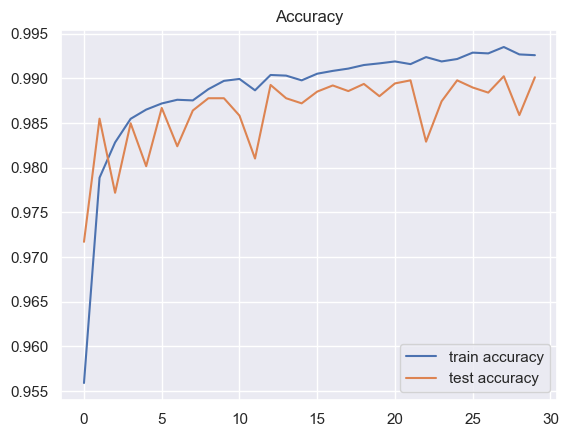

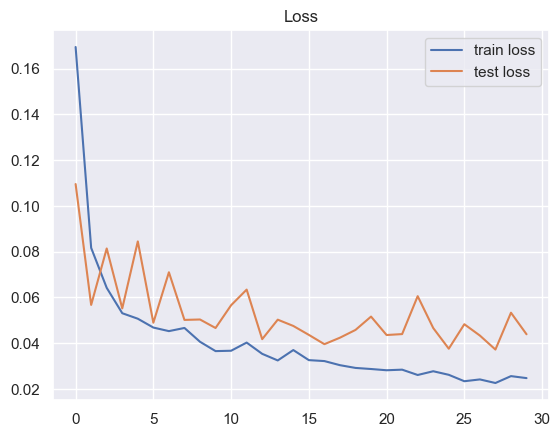

In [215]:
# plot accuracy
plt.title('Accuracy')
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='test accuracy') # label is actually 'validation accuracy'
plt.legend()
plt.show()

# plot loss
plt.title('Loss')
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='test loss') # label is actually 'validation accuracy'
plt.legend()
plt.show()

In [216]:
# Load the TensorBoard notebook extension
%load_ext tensorboard

In [217]:
%tensorboard --logdir '/Users/alstanlin/Desktop/CAT-NET for Arrhythmia Detection/logs\20221220-113542'

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "/opt/homebrew/bin/tensorboard", line 3, in <module>
    from tensorboard.main import run_main
  File "/opt/homebrew/lib/python3.10/site-packages/tensorboard/main.py", line 27, in <module>
    from tensorboard import default
  File "/opt/homebrew/lib/python3.10/site-packages/tensorboard/default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'

## **Part 6: Result**

### **Part 6.1 : Classification Accuracy and Confusion Matrix**
Akurasi klasifikasi dari keseluruhan model yang dirancang dan confusion matrix.

In [218]:
# evaluate the model

train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print('Training Accuracy: %.2f' % (train_acc*100))
print('Training Loss: %.2f' % (train_loss*100))

print('Testing Accuracy: %.2f' % (test_acc*100))
print('Testing Loss: %.2f' % (test_loss*100))

Training Accuracy: 99.35
Training Loss: 2.22
Testing Accuracy: 99.00
Testing Loss: 3.97


In [219]:
# confusion matrix
def plotHeatMap(y_test, y_pred):
    con_mat = confusion_matrix(y_test, y_pred)

    # Plotting
    plt.figure(figsize=(8, 8))
    seaborn.heatmap(con_mat, annot=True, square=True, fmt='.20g', cmap='Greens')
    plt.ylim(0, 5)
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.show()

684/684 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step


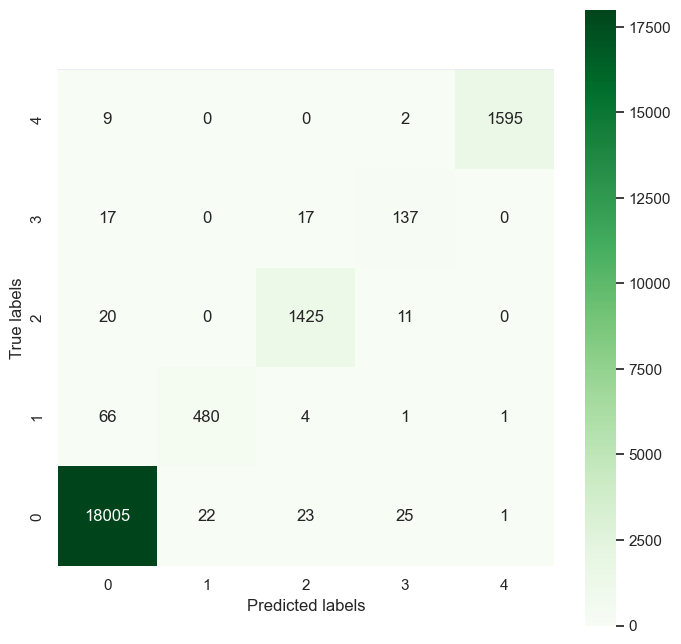

In [220]:
# predict
y_pred = np.argmax(model.predict(x_test), axis=-1)
plotHeatMap(y_test, y_pred)

### **Part 6.2 : Per Class Performance**
Menghitung nilai akurasi, sensitivitas, spesifisitas, dan F1 score dari masing-masing kelas aritmia.

In [221]:
# Per class accuracy printing function
def _report(TN, FP, FN, TP):
    TPR = TP/(TP+FN) if (TP+FN)!=0 else 0
    TNR = TN/(TN+FP) if (TN+FP)!=0 else 0
    PPV = TP/(TP+FP) if (TP+FP)!=0 else 0
    '''
    report = {'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN, 
              'TPR': TPR, 'Recall': TPR, 'Sensitivity': TPR,
              'TNR' : TNR, 'Specificity': TNR,
              'FPR': FP/(FP+TN) if (FP+TN)!=0 else 0,
              'FNR': FN/(FN+TP) if (FN+TP)!=0 else 0,
              'PPV': PPV, 'Precision': PPV,
              'F1 Score': 2*(PPV*TPR)/(PPV+TPR),
              'Per Class Accuracy': (TP+TN)/(TP+FP+FN+TN)
             }'''

    report = {'Sensitivity (%)': TPR*100,
              'Specificity (%)': TNR*100,
              'F1 Score (%)': 2*100*(PPV*TPR)/(PPV+TPR),
              'Per Class Accuracy (%)': (TP+TN)*100/(TP+FP+FN+TN)
             }
    return report

def multi_classification_report(y_test, y_pred, labels=None, encoded_labels=True, as_frame=False):
    """
    Args:
        y_test (ndarray)
        y_pred (ndarray)
        labels (list)
        encoded_labels (bool): Need to be False if labels are not one hot encoded
        as_fram (bool): If True, return type will be DataFrame
        
    Return:
        report (dict)
    """
    
    import numpy as np
    import pandas as pd
    from sklearn.metrics import multilabel_confusion_matrix
    
    conf_labels = None if encoded_labels else labels
    
    conf_mat = multilabel_confusion_matrix(y_test, y_pred, labels=conf_labels)
    report = dict()
    if labels == None:
        counter = np.arange(len(conf_mat))
    else:
        counter = labels
        
    for i, name in enumerate(counter):
        TN, FP, FN, TP = conf_mat[i].ravel()
        report[name] = _report(TN, FP, FN, TP)
    
    if as_frame:
        return pd.DataFrame(report)
    return report

In [222]:
# Per class performance
labels = ['N', 'S', 'V', 'F', 'Q']
y_pred = np.argmax(model.predict(x_test), axis=-1)
multi_classification_report(y_test, y_pred, labels=labels, encoded_labels=True, as_frame=True)

684/684 ━━━━━━━━━━━━━━━━━━━━ 30s 44ms/step


,N,S,V,F,Q
Sensitivity (%),99.607214,86.956522,97.870879,80.116959,99.315068
Specificity (%),97.040951,99.896757,99.784367,99.820194,99.990126
F1 Score (%),99.494377,91.081594,97.435897,78.962536,99.594131
Per Class Accuracy (%),99.162893,99.570011,99.656923,99.666072,99.940533
